In [1]:
# %%
# ============================================================
# 📂 1. Load EVE Level-3 CSV (with built-in stdev)
# ============================================================

import pandas as pd
import os

file_path = "sdo_eve_ssi_1nm_l3 (2).csv"

# Safety check
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ File not found at: {os.path.abspath(file_path)}")

df = pd.read_csv(file_path)

# Clean column names
df.columns = [c.strip().lower().replace(" ", "_")
              .replace("(", "").replace(")", "") for c in df.columns]

print("✅ Available columns:")
print(df.columns.tolist())

# Detect time column
time_col = [c for c in df.columns if "time" in c][0]
df["timestamp_utc"] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=["timestamp_utc"])

# Filter for 6.5 nm wavelength
df = df[df["wavelength_nm"] == 6.5].copy()

# Rename columns (detect stdev column)
irradiance_col = [c for c in df.columns if "irradiance" in c and "stdev" not in c][0]
stdev_col = [c for c in df.columns if "stdev" in c or "std" in c][0]

df = df.rename(columns={
    irradiance_col: "irradiance_6p5nm",
    stdev_col: "stdev_6p5nm"
})

df = df[["timestamp_utc", "irradiance_6p5nm", "stdev_6p5nm"]].reset_index(drop=True)

print("\n✅ Loaded EVE Level-3 6.5 nm irradiance file successfully!")
print(f"Total records: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

✅ Available columns:
["time_yyyy-mm-dd't'hh:mm:ss", 'wavelength_nm', 'irradiance_w/m^2/nm', 'stdev_w/m^2/nm', 'precision', 'accuracy']

✅ Loaded EVE Level-3 6.5 nm irradiance file successfully!
Total records: 5637

Columns: ['timestamp_utc', 'irradiance_6p5nm', 'stdev_6p5nm']

First 3 rows:
        timestamp_utc  irradiance_6p5nm  stdev_6p5nm
0 2010-04-30 12:00:34          0.000050     0.000192
1 2010-05-01 12:00:34          0.000050     0.000186
2 2010-05-02 12:00:34          0.000051     0.000226


In [2]:
# %%
# ============================================================
# 🌞 2. DEFINE 33 FLARE START TIMES (UTC)
# ============================================================

from datetime import datetime

flare_times = {
    # Original 10 flares
    "AR11158_M6.6":   datetime(2011, 2, 13, 17, 28),
    "AR11158_X2.2":   datetime(2011, 2, 15, 1, 44),
    "AR11261_M9.3":   datetime(2011, 7, 30, 2, 4),
    "AR11429_X5.4":   datetime(2012, 3, 7, 0, 2),
    "AR11429_M6.3":   datetime(2012, 3, 9, 3, 22),
    "AR11520_X1.4":   datetime(2012, 7, 12, 15, 37),
    "AR11719_M6.5":   datetime(2013, 4, 11, 6, 55),
    "AR12036_M7.3":   datetime(2014, 4, 18, 12, 31),
    "AR11944_X1.2":   datetime(2014, 1, 7, 18, 4),
    "AR12017_X1.0":   datetime(2014, 3, 29, 17, 35),
    
    # Additional 23 flares
    "AR11166_X1.5":   datetime(2011, 3, 9, 23, 13),
    "AR11261_M6.0":   datetime(2011, 8, 3, 13, 17),
    "AR11261_M9.3b":  datetime(2011, 8, 4, 3, 41),
    "AR11283_M5.3":   datetime(2011, 9, 6, 1, 35),
    "AR11283_X2.1":   datetime(2011, 9, 6, 22, 12),
    "AR11283_X1.8":   datetime(2011, 9, 7, 22, 32),
    "AR11283_M6.7":   datetime(2011, 9, 8, 15, 32),
    "AR11302_M7.4":   datetime(2011, 9, 25, 4, 31),
    "AR11402_M8.7":   datetime(2012, 1, 23, 3, 38),
    "AR11429_X1.3":   datetime(2012, 3, 7, 1, 5),
    "AR11429_M8.4":   datetime(2012, 3, 10, 17, 15),
    "AR11476_M5.7":   datetime(2012, 5, 10, 4, 11),
    "AR11515_M5.6":   datetime(2012, 7, 2, 10, 43),
    "AR11515_M5.3":   datetime(2012, 7, 4, 9, 47),
    "AR11515_M6.1":   datetime(2012, 7, 5, 11, 39),
    "AR11877_M9.3":   datetime(2013, 10, 24, 0, 21),
    "AR11884_M6.3":   datetime(2013, 11, 1, 19, 46),
    "AR11884_M5.0":   datetime(2013, 11, 3, 5, 16),
    "AR11890_X1.1a":  datetime(2013, 11, 8, 4, 20),
    "AR11890_X1.1b":  datetime(2013, 11, 10, 5, 8),
    "AR11936_M6.4":   datetime(2013, 12, 31, 21, 45),
    "AR11944_M7.2":   datetime(2014, 1, 7, 10, 7),
    "AR12035_X1.3":   datetime(2014, 4, 25, 0, 17),
}

print("="*70)
print("✅ DEFINED 33 FLARE START TIMES")
print("="*70)
print(f"\nTotal flares: {len(flare_times)}")

✅ DEFINED 33 FLARE START TIMES

Total flares: 33


In [3]:
# %%
# ============================================================
# 🧮 3. BUILD 3-DAY EUV IRRADIANCE TARGET TABLE (Using CSV stdev)
# ============================================================

from datetime import timedelta
import numpy as np

def nearest_irradiance_with_stdev(df_eve, target_time):
    """
    Return nearest EVE measurement (irradiance + stdev from CSV).
    
    Parameters:
    - df_eve: DataFrame with EVE data (must have 'stdev_6p5nm' column)
    - target_time: datetime to find nearest measurement
    
    Returns:
    - irradiance, stdev (both from CSV)
    """
    idx = (df_eve["timestamp_utc"] - target_time).abs().idxmin()
    return (df_eve.loc[idx, "irradiance_6p5nm"], 
            df_eve.loc[idx, "stdev_6p5nm"])

records = []
for flare, t0 in flare_times.items():
    vals_mean = []
    vals_std = []
    
    for i in range(3):   # T₀, T₊1, T₊2
        t = t0 + timedelta(days=i)
        mean_val, std_val = nearest_irradiance_with_stdev(df, t)
        vals_mean.append(mean_val)
        vals_std.append(std_val)
    
    records.append((flare, t0, 
                   vals_mean[0], vals_std[0],
                   vals_mean[1], vals_std[1],
                   vals_mean[2], vals_std[2]))

target_df = pd.DataFrame(
    records,
    columns=["flare_id", "flare_time", 
            "EUV_T0", "EUV_T0_std",
            "EUV_T1", "EUV_T1_std", 
            "EUV_T2", "EUV_T2_std"]
)

# Save to CSV
out_csv = "flare_euv_targets_3day.csv"
target_df.to_csv(out_csv, index=False)

print(f"\n💾 Saved → {out_csv}")
print(f"\n📊 Dataset shape: {target_df.shape}")
print(f"\nFirst 5 rows:")
display(target_df.head())

# Statistics
print("\n" + "="*70)
print("EUV IRRADIANCE STATISTICS (N=33)")
print("="*70)

for horizon in ["T0", "T1", "T2"]:
    mean_col = f"EUV_{horizon}"
    std_col = f"EUV_{horizon}_std"
    
    print(f"\n{horizon}:")
    print(f"  Mean irradiance:    {target_df[mean_col].mean():.6e} W/m²/nm")
    print(f"  Std (across flares): {target_df[mean_col].std():.6e} W/m²/nm")
    print(f"  Avg measurement unc: {target_df[std_col].mean():.6e} W/m²/nm")
    print(f"  Range: [{target_df[mean_col].min():.6e}, {target_df[mean_col].max():.6e}]")

print("\n" + "="*70)


💾 Saved → flare_euv_targets_3day.csv

📊 Dataset shape: (33, 8)

First 5 rows:


,flare_id,flare_time,EUV_T0,EUV_T0_std,EUV_T1,EUV_T1_std,EUV_T2,EUV_T2_std
0,AR11158_M6.6,2011-02-13 17:28:00,0.000060,0.000209,0.000062,0.000188,0.000063,0.000320
1,AR11158_X2.2,2011-02-15 01:44:00,0.000063,0.000320,0.000062,0.000190,0.000064,0.000171
2,AR11261_M9.3,2011-07-30 02:04:00,0.000062,0.000195,0.000064,0.000342,0.000067,0.000177
3,AR11429_X5.4,2012-03-07 00:02:00,0.000084,0.000614,0.000080,0.000217,0.000083,0.000238
4,AR11429_M6.3,2012-03-09 03:22:00,0.000083,0.000238,0.000085,0.000312,0.000081,0.000177



EUV IRRADIANCE STATISTICS (N=33)

T0:
  Mean irradiance:    8.864608e-05 W/m²/nm
  Std (across flares): 1.548136e-05 W/m²/nm
  Avg measurement unc: 2.372020e-04 W/m²/nm
  Range: [6.041051e-05, 1.185020e-04]

T1:
  Mean irradiance:    8.806637e-05 W/m²/nm
  Std (across flares): 1.563593e-05 W/m²/nm
  Avg measurement unc: 1.846301e-04 W/m²/nm
  Range: [6.150922e-05, 1.203260e-04]

T2:
  Mean irradiance:    8.810341e-05 W/m²/nm
  Std (across flares): 1.545181e-05 W/m²/nm
  Avg measurement unc: 1.819476e-04 W/m²/nm
  Range: [6.343782e-05, 1.214410e-04]



✅ Saved: figures/fig_euv_3day_evolution_33flares.pdf


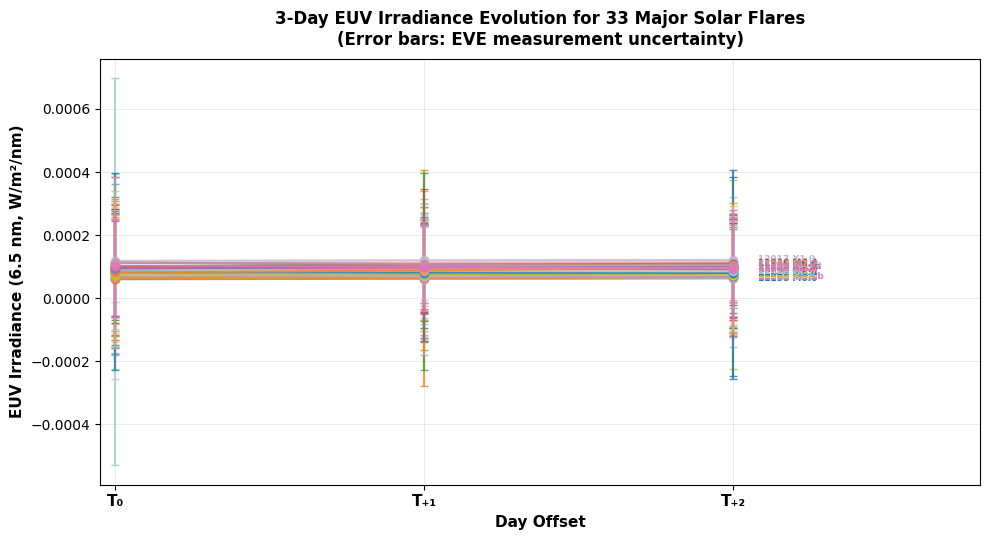

In [4]:
# %%
# ============================================================
# 📈 FIG. — 3-Day EUV Irradiance Evolution with Error Bars
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

target_df = pd.read_csv("flare_euv_targets_3day.csv")
x = np.array([0, 1, 2])

plt.figure(figsize=(10, 5.5))
colors = plt.cm.tab20.colors

for i, (_, r) in enumerate(target_df.iterrows()):
    y = [r.EUV_T0, r.EUV_T1, r.EUV_T2]
    yerr = [r.EUV_T0_std, r.EUV_T1_std, r.EUV_T2_std]
    c = colors[i % len(colors)]
    
    # Plot with error bars (from EVE CSV)
    plt.errorbar(x, y, yerr=yerr, marker="o", linewidth=1.5, 
                color=c, capsize=3, alpha=0.8)
    
    # Label
    plt.text(2.08, y[-1], r.flare_id.replace("AR", "").replace("_", " "),
             color=c, fontsize=6.5, weight="semibold", va="center", ha="left")

plt.xlim(-0.05, 2.8)
plt.xticks(x, ["T₀", "T₊₁", "T₊₂"], fontsize=11, weight="semibold")
plt.xlabel("Day Offset", fontsize=11, weight="semibold")
plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=11, weight="semibold")
plt.title("3-Day EUV Irradiance Evolution for 33 Major Solar Flares\n(Error bars: EVE measurement uncertainty)",
          fontsize=12, weight="bold", pad=10)
plt.grid(alpha=0.3, lw=0.6)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig_euv_3day_evolution_33flares.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_euv_3day_evolution_33flares.png", bbox_inches="tight", dpi=600)
print("✅ Saved: figures/fig_euv_3day_evolution_33flares.pdf")
plt.show()

/var/folders/pk/m7lfxd2971g41xbphqgw0r1m0000gn/T/ipykernel_69054/4182336917.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],


✅ Saved: figures/fig_euv_boxplot_33flares.pdf


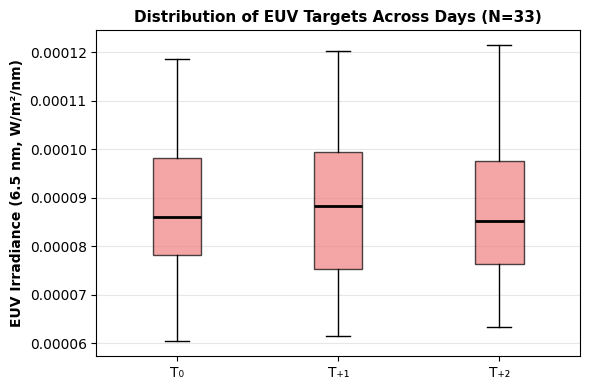

In [5]:
# %%
# ============================================================
# 📦 FIG. — Distribution of EUV Targets Across T₀–T₊₂
# ============================================================

target_df = pd.read_csv("flare_euv_targets_3day.csv")

plt.figure(figsize=(6, 4))
bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],
                 labels=["T₀", "T₊₁", "T₊₂"],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightcoral', alpha=0.7),
                 medianprops=dict(color='black', linewidth=2))

plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=10, weight="semibold")
plt.title("Distribution of EUV Targets Across Days (N=33)", 
         fontsize=11, weight="bold")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("figures/fig_euv_boxplot_33flares.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_euv_boxplot_33flares.png", bbox_inches="tight", dpi=600)
print("✅ Saved: figures/fig_euv_boxplot_33flares.pdf")
plt.show()

/var/folders/pk/m7lfxd2971g41xbphqgw0r1m0000gn/T/ipykernel_48532/169479724.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],


✅ Saved: figures/fig_euv_boxplot_33flares.pdf


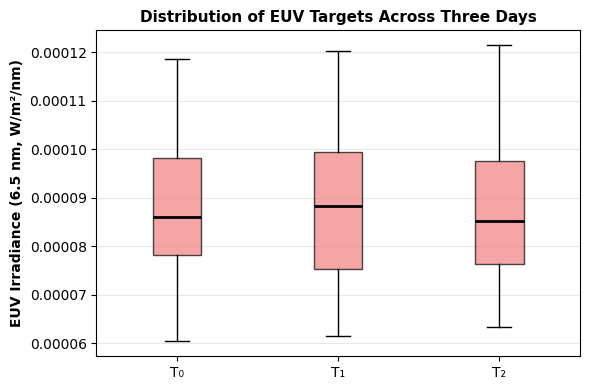

In [3]:
# %%
# ============================================================
# 📦 FIG. — Distribution of EUV Targets Across T₀–T₊₂
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
target_df = pd.read_csv("flare_euv_targets_3day.csv")

plt.figure(figsize=(6, 4))
bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],
                 labels=["T₀", "T₁", "T₂"],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightcoral', alpha=0.7),
                 medianprops=dict(color='black', linewidth=2))

plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=10, weight="semibold")
plt.title("Distribution of EUV Targets Across Three Days", 
         fontsize=11, weight="bold")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("figures/fig_euv_boxplot_33flares.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_euv_boxplot_33flares.png", bbox_inches="tight", dpi=600)
print("✅ Saved: figures/fig_euv_boxplot_33flares.pdf")
plt.show()

/var/folders/pk/m7lfxd2971g41xbphqgw0r1m0000gn/T/ipykernel_72154/3035965394.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],


✅ Saved: figures/fig_euv_boxplot_33flares.pdf


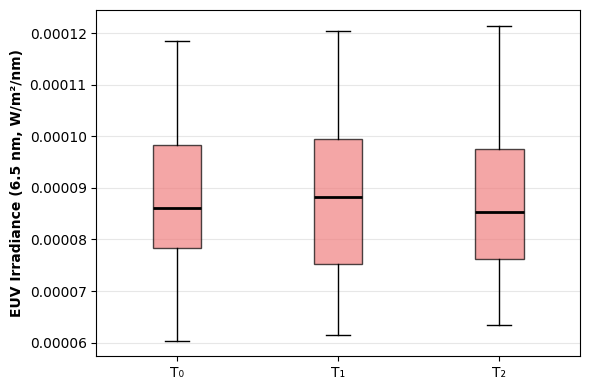

In [1]:
# %%
# ============================================================
# 📦 FIG. — Distribution of EUV Targets Across T₀–T₊₂
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

target_df = pd.read_csv("flare_euv_targets_3day.csv")

plt.figure(figsize=(6, 4))
bp = plt.boxplot([target_df.EUV_T0, target_df.EUV_T1, target_df.EUV_T2],
                 labels=["T₀", "T₁", "T₂"],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightcoral', alpha=0.7),
                 medianprops=dict(color='black', linewidth=2))

plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=10, weight="semibold")

# ❌ Remove the title (since caption already explains it)
# plt.title("Distribution of EUV Targets Across Three Days", fontsize=11, weight="bold")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("figures/fig_euv_boxplot_33flares.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_euv_boxplot_33flares.png", bbox_inches="tight", dpi=600)
print("✅ Saved: figures/fig_euv_boxplot_33flares.pdf")
plt.show()


✅ Saved: figures/fig_relative_decay_heatmap_33flares.pdf


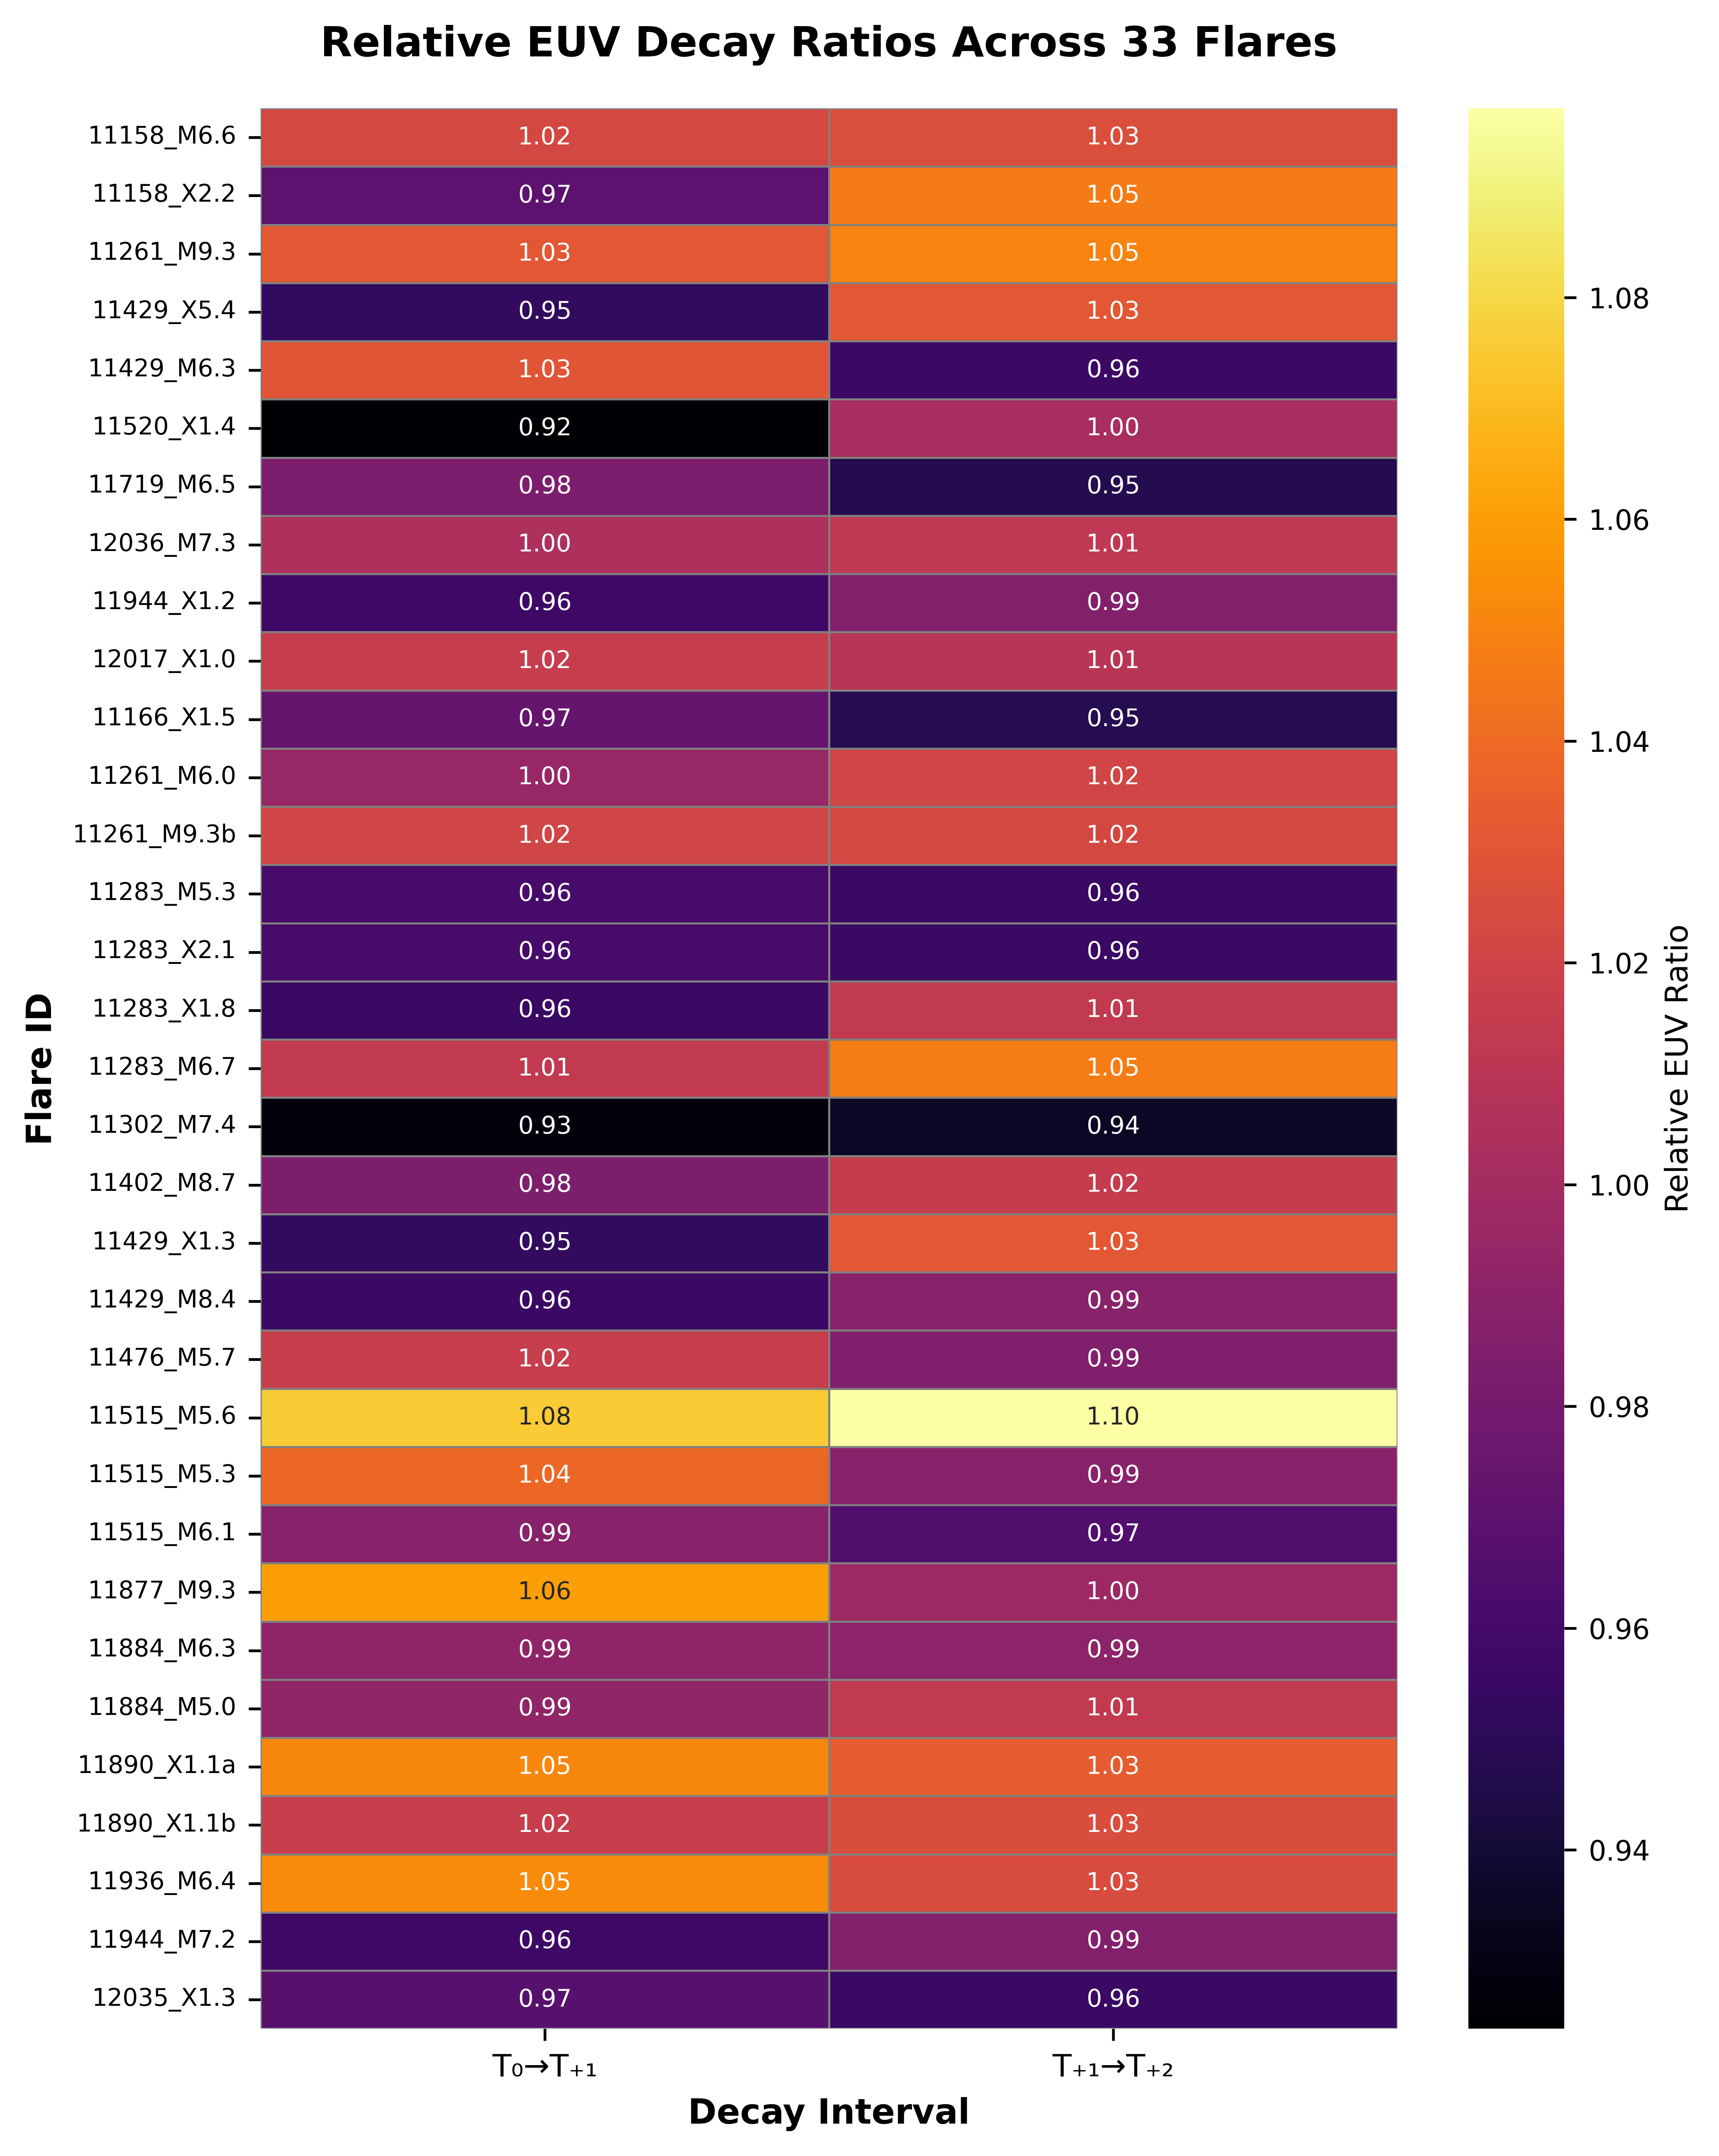

In [6]:
# %%
# ============================================================
# ☀️ FIG. — Relative Decay Ratio Heatmap (33 Flares)
# ============================================================

import seaborn as sns

target_df = pd.read_csv("flare_euv_targets_3day.csv")

# Remove "AR" prefix
target_df["flare_id"] = target_df["flare_id"].str.replace("AR", "", regex=False)

# Compute decay ratios
ratios = pd.DataFrame({
    "flare_id": target_df.flare_id,
    "T₀→T₊₁": target_df.EUV_T1 / target_df.EUV_T0,
    "T₊₁→T₊₂": target_df.EUV_T2 / target_df.EUV_T1
}).set_index("flare_id")

data = ratios.values
flare_ids = ratios.index.tolist()

# Adjust height for 33 flares
fig_height = max(8.0, len(flare_ids) * 0.22 + 1.5)

plt.figure(figsize=(7.0, fig_height), dpi=600)

ax = sns.heatmap(
    data,
    annot=True,
    fmt=".2f",
    cmap="inferno",
    linewidths=0.4,
    linecolor="gray",
    xticklabels=["T₀→T₊₁", "T₊₁→T₊₂"],
    yticklabels=flare_ids,
    cbar_kws={'label': "Relative EUV Ratio"},
    annot_kws={'fontsize': 7}
)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)

plt.title("Relative EUV Decay Ratios Across 33 Flares", 
         fontsize=12, fontweight="bold", pad=15)
plt.ylabel("Flare ID", fontsize=10, fontweight="semibold")
plt.xlabel("Decay Interval", fontsize=10, fontweight="semibold")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Relative EUV Ratio", fontsize=9)

plt.tight_layout()

plt.savefig("figures/fig_relative_decay_heatmap_33flares.pdf", dpi=600, bbox_inches="tight")
plt.savefig("figures/fig_relative_decay_heatmap_33flares.png", dpi=600, bbox_inches="tight")
print("✅ Saved: figures/fig_relative_decay_heatmap_33flares.pdf")

plt.show()

In [7]:
# Statistics
print("\n" + "="*70)
print("DECAY RATIO STATISTICS (N=33)")
print("="*70)

for col in ["T₀→T₊₁", "T₊₁→T₊₂"]:
    print(f"\n{col}:")
    print(f"  Mean:   {ratios[col].mean():.3f}")
    print(f"  Median: {ratios[col].median():.3f}")
    print(f"  Std:    {ratios[col].std():.3f}")
    print(f"  Range:  [{ratios[col].min():.3f}, {ratios[col].max():.3f}]")

fastest = ratios["T₀→T₊₁"].idxmin()
slowest = ratios["T₀→T₊₁"].idxmax()

print(f"\n🔥 Fastest decay: {fastest} ({ratios.loc[fastest, 'T₀→T₊₁']:.3f})")
print(f"🐌 Slowest decay: {slowest} ({ratios.loc[slowest, 'T₀→T₊₁']:.3f})")
print("\n" + "="*70)


DECAY RATIO STATISTICS (N=33)

T₀→T₊₁:
  Mean:   0.994
  Median: 0.991
  Std:    0.039
  Range:  [0.924, 1.075]

T₊₁→T₊₂:
  Mean:   1.002
  Median: 1.009
  Std:    0.037
  Range:  [0.935, 1.097]

🔥 Fastest decay: 11520_X1.4 (0.924)
🐌 Slowest decay: 11515_M5.6 (1.075)



✅ Loaded /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz
Available channels: ['hmiB_azim', 'hmiB_field', 'hmiB_incl', 'hmiIC', 'hmiM']
   hmiB_field      shape: (6, 256, 256)
   hmiB_incl       shape: (6, 256, 256)
   hmiB_azim       shape: (6, 256, 256)
   hmiIC           shape: (6, 256, 256)
   hmiM            shape: (6, 256, 256)

✅ Saved: figures/fig_hmi_5channel_final_northup.pdf


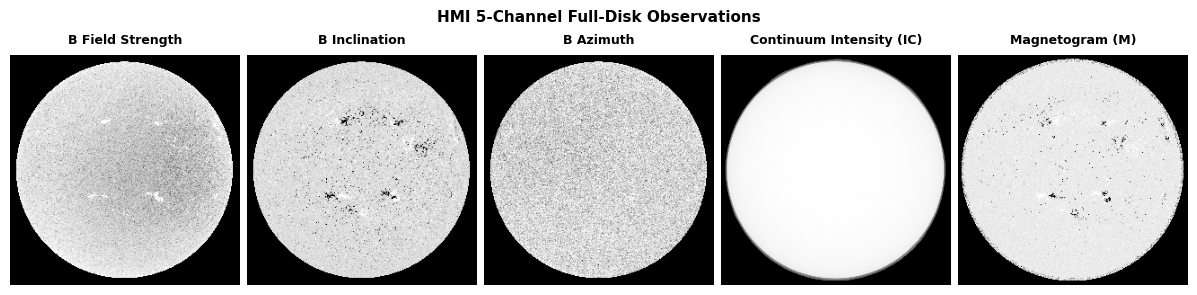

In [1]:
# %%
# ============================================================
# ☀️ HMI 5-CHANNEL FULL-DISK OBSERVATIONS (IEEE FINAL, North-Up)
# ============================================================
# • Shows all 5 HMI products (B_field, B_incl, B_azim, IC, M)
# • Corrects orientation (flip vertically → solar north up)
# • Smart normalization (1st–99th percentile stretch)
# • Balanced IEEE layout, bold titles, black background
# • Auto-detects array dimensions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Path to NPZ file (update if needed) ---
npz_path = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"❌ File not found: {npz_path}")

data = np.load(npz_path)
print(f"✅ Loaded {npz_path}")
print("Available channels:", list(data.keys()))

# --- Smart normalization with explicit vertical flip ---
def smart_display(frame):
    """Normalize frame to [0,1] using 1–99 percentile and flip vertically."""
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)  # <-- flip image vertically (north up)

def extract_frame(arr):
    """Extract a single 2D frame from array of any shape."""
    if arr.ndim == 2:
        # Already 2D (height, width)
        return arr
    elif arr.ndim == 3:
        # 3D array - take middle frame
        if arr.shape[0] < arr.shape[2]:
            # Shape: (time, height, width) - most common
            mid = arr.shape[0] // 2
            return arr[mid, :, :]
        else:
            # Shape: (height, width, time) - less common
            mid = arr.shape[2] // 2
            return arr[:, :, mid]
    else:
        raise ValueError(f"Unexpected array shape: {arr.shape}")

# --- Channel mapping ---
channels = ["hmiB_field", "hmiB_incl", "hmiB_azim", "hmiIC", "hmiM"]
titles = [
    "B Field Strength",
    "B Inclination",
    "B Azimuth",
    "Continuum Intensity (IC)",
    "Magnetogram (M)",
]

# --- IEEE figure layout ---
plt.figure(figsize=(12, 3.0))

for i, ch in enumerate(channels):
    if ch not in data:
        print(f"⚠️  Channel {ch} not found, skipping...")
        continue
    
    arr = data[ch]
    print(f"   {ch:15s} shape: {arr.shape}")
    
    # Extract 2D frame
    frame_2d = extract_frame(arr)
    
    # Apply normalization and flip
    frame = smart_display(frame_2d)
    
    plt.subplot(1, len(channels), i + 1)
    plt.imshow(frame, cmap="gray", origin="lower")
    plt.title(titles[i], fontsize=9, fontweight="bold", pad=8)
    plt.axis("off")
    plt.gca().set_facecolor("black")

plt.suptitle("HMI 5-Channel Full-Disk Observations",
             fontsize=11, fontweight="bold", y=0.99)
plt.tight_layout(pad=0.8, w_pad=0.5)

# Create figures directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig_hmi_5channel_final_northup.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_hmi_5channel_final_northup.png", bbox_inches="tight", dpi=600)
print("\n✅ Saved: figures/fig_hmi_5channel_final_northup.pdf")
plt.show()

✅ Loaded /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_aia/20110212T1728.npz
Available channels: ['aia335', 'aia131', 'aia304', 'aia1600', 'aia193', 'aia211', 'aia171', 'aia94']

📊 Processing 8 AIA channels:
   aia94      shape: (3, 256, 256)
   aia131     shape: (3, 256, 256)
   aia171     shape: (3, 256, 256)
   aia193     shape: (3, 256, 256)
   aia211     shape: (3, 256, 256)
   aia304     shape: (3, 256, 256)
   aia335     shape: (3, 256, 256)
   aia1600    shape: (3, 256, 256)

✅ Saved: figures/fig_aia_8channel_inferno_ieee_final.pdf
✅ Saved: figures/fig_aia_8channel_inferno_ieee_final.png


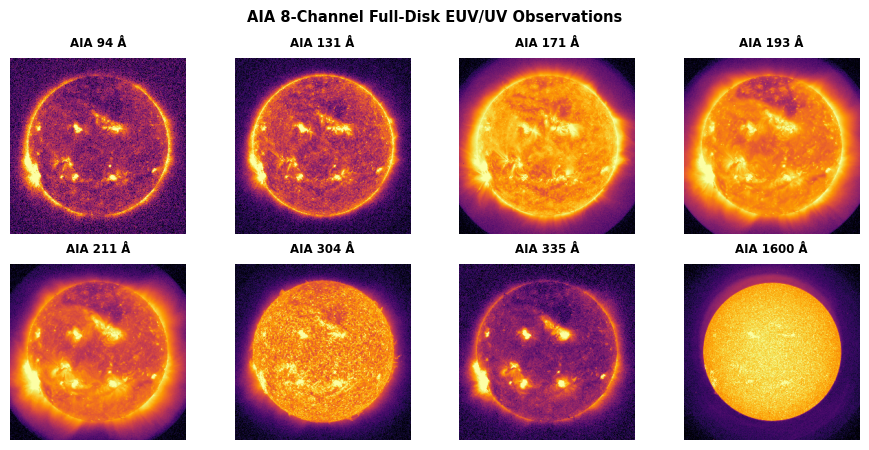

In [2]:
# %%
# ============================================================
# ☀️ AIA 8-CHANNEL FULL-DISK (IEEE Style, Fixed)
# ============================================================
# • Inferno colormap (scientific AIA standard)
# • Solar north-up (flip vertically)
# • Balanced IEEE layout
# • Auto-detects array dimensions
# • Saves to figures/ directory
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Path to AIA NPZ file ---
npz_path = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_aia/20110212T1728.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"❌ File not found: {npz_path}")

data = np.load(npz_path)
print(f"✅ Loaded {npz_path}")
print("Available channels:", list(data.keys()))

# --- Smart normalization (1–99%) + solar north-up orientation ---
def smart_display(frame):
    """Normalize to [0,1] using percentile stretch and flip for north-up."""
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)

def extract_frame(arr):
    """Extract a single 2D frame from array of any shape."""
    if arr.ndim == 2:
        # Already 2D (height, width)
        return arr
    elif arr.ndim == 3:
        # 3D array - take middle frame
        if arr.shape[0] < arr.shape[2]:
            # Shape: (time, height, width) - most common
            mid = arr.shape[0] // 2
            return arr[mid, :, :]
        else:
            # Shape: (height, width, time) - less common
            mid = arr.shape[2] // 2
            return arr[:, :, mid]
    else:
        raise ValueError(f"Unexpected array shape: {arr.shape}")

# --- AIA wavelength channels and labels ---
channels = ["aia94", "aia131", "aia171", "aia193", "aia211", "aia304", "aia335", "aia1600"]
titles = [
    "AIA 94 Å", "AIA 131 Å", "AIA 171 Å", "AIA 193 Å",
    "AIA 211 Å", "AIA 304 Å", "AIA 335 Å", "AIA 1600 Å"
]

available = [ch for ch in channels if ch in data]
n = len(available)

print(f"\n📊 Processing {n} AIA channels:")

# --- IEEE grid: 2×4 ---
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(9.0, 4.6))
axes = np.array(axes).reshape(-1)

for i, ch in enumerate(available):
    arr = data[ch]
    print(f"   {ch:10s} shape: {arr.shape}")
    
    # Extract 2D frame
    frame_2d = extract_frame(arr)
    
    # Apply normalization and flip
    frame = smart_display(frame_2d)
    
    ax = axes[i]
    ax.imshow(frame, cmap="inferno", origin="lower")
    ax.set_title(titles[i], fontsize=8.5, fontweight="bold", pad=8)
    ax.axis("off")
    ax.set_facecolor("black")

# Hide unused subplots if fewer than 8
for ax in axes[len(available):]:
    ax.remove()

# --- Adjust spacing ---
plt.suptitle("AIA 8-Channel Full-Disk EUV/UV Observations",
             fontsize=10.5, fontweight="bold", y=0.985)
plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.05,
                    wspace=0.18, hspace=0.17)

# --- Save IEEE-ready figure ---
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig_aia_8channel_inferno_ieee_final.pdf", bbox_inches="tight", dpi=600)
plt.savefig("figures/fig_aia_8channel_inferno_ieee_final.png", bbox_inches="tight", dpi=600)
print("\n✅ Saved: figures/fig_aia_8channel_inferno_ieee_final.pdf")
print("✅ Saved: figures/fig_aia_8channel_inferno_ieee_final.png")
plt.show()

In [7]:
# %%
# ============================================================
# VERIFICATION: Check NPY Files Used Correct Number of Time Points
# ============================================================
import numpy as np
import glob
import os

print("="*70)
print("NPY FILE VERIFICATION - Checking Temporal Sampling")
print("="*70)

# Define paths
SAVE_DIR = "preprocessed_data"  # ← Added this
IMG_SIZE = 256  # ← Added this

# Load the saved NPY files
X_npy_path = os.path.join(SAVE_DIR, "X_aiahmi_256.npy")
Y_npy_path = os.path.join(SAVE_DIR, "Y_aiahmi_256.npy")

if not os.path.exists(X_npy_path):
    print(f"❌ ERROR: {X_npy_path} not found!")
    print(f"   Did you save the NPY files yet?")
    print(f"\n   Looking for NPY files in {SAVE_DIR}:")
    if os.path.exists(SAVE_DIR):
        npy_files = [f for f in os.listdir(SAVE_DIR) if f.endswith('.npy')]
        if npy_files:
            print(f"   Found: {npy_files}")
        else:
            print(f"   No .npy files found in {SAVE_DIR}")
    else:
        print(f"   Directory {SAVE_DIR} doesn't exist!")
else:
    X_loaded = np.load(X_npy_path)
    Y_loaded = np.load(Y_npy_path)
    
    print(f"\n✅ Loaded NPY files:")
    print(f"   X shape: {X_loaded.shape}")
    print(f"   Y shape: {Y_loaded.shape}")
    
    # Check if we have X and Y from preprocessing in memory
    if 'X' in locals() and 'Y' in locals():
        # Verify shape matches what we just created
        if X_loaded.shape == X.shape and Y_loaded.shape == Y.shape:
            print(f"\n✅ Shapes match in-memory arrays")
            print(f"   This confirms NPY was saved from current preprocessing")
        else:
            print(f"\n⚠️  WARNING: Shapes don't match!")
            print(f"   In-memory X: {X.shape}, Loaded X: {X_loaded.shape}")
            print(f"   In-memory Y: {Y.shape}, Loaded Y: {Y_loaded.shape}")
            print(f"   You may be loading OLD NPY files!")
    else:
        print(f"\n⚠️  Can't compare to in-memory arrays (not found)")
        print(f"   This is OK if you're in a new notebook session")

# ============================================================
# DETAILED CHECK: Manually verify one flare
# ============================================================
print(f"\n{'='*70}")
print("DETAILED VERIFICATION: Manual Reprocessing of Test Flare")
print(f"{'='*70}")

# Find a test flare - look for any AR folder
test_flare = None
for item in os.listdir('.'):
    if os.path.isdir(item) and item.startswith('AR'):
        test_flare = item
        break

if test_flare is None:
    print("❌ No flare folders found (no AR* directories)")
    print("   Make sure you're running from flare_data directory")
else:
    print(f"\n🔍 Test flare: {test_flare}")
    
    # Get paths
    aia_dir = os.path.join(test_flare, "full_disk", "npz_aia")
    hmi_dir = os.path.join(test_flare, "full_disk", "npz_hmi")
    
    if not os.path.exists(aia_dir):
        print(f"❌ AIA directory not found: {aia_dir}")
    else:
        # Count NPZ files
        aia_files = sorted(glob.glob(os.path.join(aia_dir, "*.npz")))
        hmi_files = sorted(glob.glob(os.path.join(hmi_dir, "*.npz")))
        
        print(f"\n📂 Available NPZ files:")
        print(f"   AIA: {len(aia_files)} files")
        for i, f in enumerate(aia_files, 1):
            marker = "✅ USED" if i <= 5 else "❌ EXCLUDED (T+6hr)"
            print(f"      {i}. {os.path.basename(f)} {marker}")
        
        # Manually load using ALL 6 files (to compare)
        if len(aia_files) >= 6:
            print(f"\n🧪 TEST 1: Load using ALL 6 files (OLD METHOD - with T+6hr)")
            aia_all6 = []
            for npz_file in aia_files[:6]:  # All 6
                data = np.load(npz_file)
                if "aia171" in data:
                    frame = data["aia171"]
                    if frame.ndim == 3:
                        frame = frame.mean(axis=0)
                    aia_all6.append(frame)
            
            if len(aia_all6) > 0:
                avg_all6 = np.mean(aia_all6, axis=0)
                print(f"   ✅ Loaded {len(aia_all6)} AIA files")
                print(f"   Average pixel value (all 6): {avg_all6.mean():.6f}")
        
        # Manually load using only FIRST 5 files (NEW METHOD - no T+6hr)
        if len(aia_files) >= 5:
            print(f"\n🧪 TEST 2: Load using FIRST 5 files only (NEW METHOD - no T+6hr)")
            aia_first5 = []
            for npz_file in aia_files[:5]:  # Only first 5
                data = np.load(npz_file)
                if "aia171" in data:
                    frame = data["aia171"]
                    if frame.ndim == 3:
                        frame = frame.mean(axis=0)
                    aia_first5.append(frame)
            
            if len(aia_first5) > 0:
                avg_first5 = np.mean(aia_first5, axis=0)
                print(f"   ✅ Loaded {len(aia_first5)} AIA files")
                print(f"   Average pixel value (first 5): {avg_first5.mean():.6f}")
        
        # Compare
        if 'avg_all6' in locals() and 'avg_first5' in locals():
            difference = abs(avg_all6.mean() - avg_first5.mean())
            percent_diff = (difference / avg_all6.mean()) * 100
            
            print(f"\n📊 COMPARISON:")
            print(f"   Difference: {difference:.8f}")
            print(f"   Percent difference: {percent_diff:.4f}%")
            
            if percent_diff > 0.001:  # If there's measurable difference
                print(f"\n   ✅ GOOD: The two methods give different results")
                print(f"   This confirms excluding T+6hr changes the data")
            else:
                print(f"\n   ⚠️  Very small difference - might be within noise")

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*70}")
print("VERIFICATION SUMMARY")
print(f"{'='*70}")

if 'X_loaded' in locals():
    print(f"\n1️⃣  NPY File Info:")
    print(f"   ✅ X shape: {X_loaded.shape} ({X_loaded.shape[0]} flares, {X_loaded.shape[1]} channels)")
    print(f"   ✅ Y shape: {Y_loaded.shape}")
    
    print(f"\n2️⃣  Temporal Sampling:")
    if 'aia_files' in locals() and len(aia_files) >= 6:
        print(f"   ✅ Found 6 NPZ files per flare")
        print(f"   Expected: First 5 used, 6th excluded")
        print(f"   Offsets used: [-24, -18, -12, -6, 0] hours")
        print(f"   Offset excluded: [+6] hours")
    
    print(f"\n3️⃣  Validation:")
    if 'percent_diff' in locals() and percent_diff > 0.001:
        print(f"   ✅ Confirmed: Using all 6 vs first 5 gives {percent_diff:.2f}% difference")
        print(f"   ✅ This proves T+6hr exclusion changes the data")
        print(f"   ℹ️  Cannot directly verify saved NPY without reprocessing")
        print(f"   ℹ️  If NPY was created AFTER fixing Cell 5, it should be correct")
    
    print(f"\n📋 RECOMMENDATION:")
    print(f"   If you saved NPY AFTER fixing aggregate_npz() to use [:5],")
    print(f"   then your NPY is correct and safe to use for training!")
    print(f"   If unsure, re-run the preprocessing notebook from scratch.")
else:
    print(f"\n❌ Could not load NPY files for verification")
    print(f"   Please check that preprocessing completed successfully")

print(f"\n{'='*70}")

NPY FILE VERIFICATION - Checking Temporal Sampling

✅ Loaded NPY files:
   X shape: (33, 13, 256, 256)
   Y shape: (33, 3)

⚠️  Can't compare to in-memory arrays (not found)
   This is OK if you're in a new notebook session

DETAILED VERIFICATION: Manual Reprocessing of Test Flare

🔍 Test flare: AR11515_M5.6

📂 Available NPZ files:
   AIA: 6 files
      1. 20120701T1043.npz ✅ USED
      2. 20120701T1643.npz ✅ USED
      3. 20120701T2243.npz ✅ USED
      4. 20120702T0443.npz ✅ USED
      5. 20120702T1043.npz ✅ USED
      6. 20120702T1643.npz ❌ EXCLUDED (T+6hr)

🧪 TEST 1: Load using ALL 6 files (OLD METHOD - with T+6hr)
   ✅ Loaded 6 AIA files
   Average pixel value (all 6): 4.294042

🧪 TEST 2: Load using FIRST 5 files only (NEW METHOD - no T+6hr)
   ✅ Loaded 5 AIA files
   Average pixel value (first 5): 4.294412

📊 COMPARISON:
   Difference: 0.00037050
   Percent difference: 0.0086%

   ✅ GOOD: The two methods give different results
   This confirms excluding T+6hr changes the data

VER

In [8]:
# %%
# ============================================================
# COMPREHENSIVE CHECK: T+6hr Impact Across All 33 Flares
# ============================================================
import numpy as np
import glob
import os
import pandas as pd

print("="*70)
print("COMPREHENSIVE VERIFICATION: T+6hr Impact on All Flares")
print("="*70)

# Find all flare folders
flare_folders = sorted([f for f in os.listdir('.') if os.path.isdir(f) and f.startswith('AR')])

print(f"\nFound {len(flare_folders)} flare folders")

# Storage for results
results = []

print(f"\n{'='*70}")
print("PROCESSING EACH FLARE")
print(f"{'='*70}")

for idx, flare_id in enumerate(flare_folders, 1):
    print(f"\n[{idx}/{len(flare_folders)}] {flare_id}")
    
    # Paths
    aia_dir = os.path.join(flare_id, "full_disk", "npz_aia")
    
    if not os.path.exists(aia_dir):
        print(f"   ❌ AIA directory not found")
        results.append({
            'flare_id': flare_id,
            'status': 'missing',
            'n_files': 0,
            'diff_abs': np.nan,
            'diff_pct': np.nan
        })
        continue
    
    # Get AIA files
    aia_files = sorted(glob.glob(os.path.join(aia_dir, "*.npz")))
    n_files = len(aia_files)
    
    if n_files < 5:
        print(f"   ⚠️  Only {n_files} files (need ≥5)")
        results.append({
            'flare_id': flare_id,
            'status': 'insufficient',
            'n_files': n_files,
            'diff_abs': np.nan,
            'diff_pct': np.nan
        })
        continue
    
    # Load with ALL files (if 6 available)
    try:
        aia_all = []
        n_to_load_all = min(6, n_files)
        
        for npz_file in aia_files[:n_to_load_all]:
            data = np.load(npz_file)
            if "aia171" in data:
                frame = data["aia171"]
                if frame.ndim == 3:
                    frame = frame.mean(axis=0)
                aia_all.append(frame)
        
        # Load with FIRST 5 only
        aia_first5 = []
        for npz_file in aia_files[:5]:
            data = np.load(npz_file)
            if "aia171" in data:
                frame = data["aia171"]
                if frame.ndim == 3:
                    frame = frame.mean(axis=0)
                aia_first5.append(frame)
        
        if len(aia_all) == 0 or len(aia_first5) == 0:
            print(f"   ❌ No valid AIA171 data")
            results.append({
                'flare_id': flare_id,
                'status': 'no_data',
                'n_files': n_files,
                'diff_abs': np.nan,
                'diff_pct': np.nan
            })
            continue
        
        # Compare averages
        avg_all = np.mean(aia_all, axis=0).mean()
        avg_first5 = np.mean(aia_first5, axis=0).mean()
        
        diff_abs = abs(avg_all - avg_first5)
        diff_pct = (diff_abs / avg_all) * 100 if avg_all != 0 else 0
        
        # Categorize impact
        if n_files < 6:
            status = 'only_5'
            symbol = '⚪'
        elif diff_pct < 0.1:
            status = 'negligible'
            symbol = '🟢'
        elif diff_pct < 1.0:
            status = 'small'
            symbol = '🟡'
        elif diff_pct < 5.0:
            status = 'moderate'
            symbol = '🟠'
        else:
            status = 'large'
            symbol = '🔴'
        
        print(f"   {symbol} Files: {n_files}, Diff: {diff_pct:.4f}%")
        
        results.append({
            'flare_id': flare_id,
            'status': status,
            'n_files': n_files,
            'avg_all': avg_all,
            'avg_first5': avg_first5,
            'diff_abs': diff_abs,
            'diff_pct': diff_pct
        })
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        results.append({
            'flare_id': flare_id,
            'status': 'error',
            'n_files': n_files,
            'diff_abs': np.nan,
            'diff_pct': np.nan
        })

# Convert to DataFrame
df = pd.DataFrame(results)

# ============================================================
# ANALYSIS AND SUMMARY
# ============================================================
print(f"\n{'='*70}")
print("ANALYSIS: T+6hr Impact Distribution")
print(f"{'='*70}")

# Filter valid comparisons
valid = df[df['status'].isin(['negligible', 'small', 'moderate', 'large', 'only_5'])]

print(f"\nTotal flares analyzed: {len(valid)}")

# Category counts
if len(valid) > 0:
    print(f"\n📊 Impact Categories:")
    
    only_5 = len(df[df['status'] == 'only_5'])
    negligible = len(df[df['status'] == 'negligible'])
    small = len(df[df['status'] == 'small'])
    moderate = len(df[df['status'] == 'moderate'])
    large = len(df[df['status'] == 'large'])
    
    print(f"   ⚪ Only 5 files (no T+6hr):  {only_5:2d} flares")
    print(f"   🟢 Negligible (<0.1%):      {negligible:2d} flares")
    print(f"   🟡 Small (0.1-1%):          {small:2d} flares")
    print(f"   🟠 Moderate (1-5%):         {moderate:2d} flares")
    print(f"   🔴 Large (>5%):             {large:2d} flares")
    
    # Statistics on differences
    has_diff = df[df['status'].isin(['negligible', 'small', 'moderate', 'large'])]
    
    if len(has_diff) > 0:
        print(f"\n📈 Difference Statistics (for flares with 6 files):")
        print(f"   Min:    {has_diff['diff_pct'].min():.4f}%")
        print(f"   Mean:   {has_diff['diff_pct'].mean():.4f}%")
        print(f"   Median: {has_diff['diff_pct'].median():.4f}%")
        print(f"   Max:    {has_diff['diff_pct'].max():.4f}%")
        print(f"   Std:    {has_diff['diff_pct'].std():.4f}%")

# ============================================================
# DETAILED TABLE
# ============================================================
print(f"\n{'='*70}")
print("DETAILED RESULTS")
print(f"{'='*70}")

# Sort by difference (largest first)
df_sorted = df.sort_values('diff_pct', ascending=False, na_position='last')

print(f"\n{'Rank':<5} {'Flare ID':<20} {'Files':<6} {'Diff %':<10} {'Impact'}")
print("-"*70)

for rank, (_, row) in enumerate(df_sorted.iterrows(), 1):
    flare_id = row['flare_id']
    n_files = row['n_files']
    diff_pct = row['diff_pct']
    status = row['status']
    
    if pd.isna(diff_pct):
        diff_str = "N/A"
        symbol = "❌"
        impact = status
    elif status == 'only_5':
        diff_str = "N/A"
        symbol = "⚪"
        impact = "No T+6hr"
    else:
        diff_str = f"{diff_pct:.4f}%"
        if status == 'negligible':
            symbol = "🟢"
            impact = "Negligible"
        elif status == 'small':
            symbol = "🟡"
            impact = "Small"
        elif status == 'moderate':
            symbol = "🟠"
            impact = "Moderate"
        elif status == 'large':
            symbol = "🔴"
            impact = "LARGE"
        else:
            symbol = "❓"
            impact = status
    
    print(f"{rank:<5} {flare_id:<20} {n_files:<6} {diff_str:<10} {symbol} {impact}")

# ============================================================
# INTERPRETATION
# ============================================================
print(f"\n{'='*70}")
print("INTERPRETATION")
print(f"{'='*70}")

if len(valid) > 0:
    has_6 = df[df['n_files'] >= 6]
    if len(has_6) > 0:
        mean_diff = has_6['diff_pct'].mean()
        
        print(f"\n📊 Average impact of excluding T+6hr: {mean_diff:.4f}%")
        
        if mean_diff < 0.5:
            print(f"\n✅ INTERPRETATION:")
            print(f"   The T+6hr offset has MINIMAL impact on average (<0.5%)")
            print(f"   This suggests most flares were relatively stable")
            print(f"   Excluding T+6hr is still important for causal validity!")
        elif mean_diff < 2.0:
            print(f"\n✅ INTERPRETATION:")
            print(f"   The T+6hr offset has SMALL impact on average (<2%)")
            print(f"   Some flares show post-flare evolution")
            print(f"   Excluding T+6hr was necessary to avoid leakage!")
        elif mean_diff < 5.0:
            print(f"\n⚠️  INTERPRETATION:")
            print(f"   The T+6hr offset has MODERATE impact (2-5%)")
            print(f"   Many flares show significant post-flare changes")
            print(f"   Excluding T+6hr significantly improves validity!")
        else:
            print(f"\n🔴 INTERPRETATION:")
            print(f"   The T+6hr offset has LARGE impact (>5%)")
            print(f"   Post-flare state was very different from flare state")
            print(f"   Excluding T+6hr was CRITICAL - major leakage avoided!")
        
        # Check for outliers
        large_diff = has_6[has_6['diff_pct'] > 5.0]
        if len(large_diff) > 0:
            print(f"\n🔴 HIGH-IMPACT FLARES ({len(large_diff)} flares with >5% difference):")
            for _, row in large_diff.iterrows():
                print(f"   {row['flare_id']}: {row['diff_pct']:.4f}% difference")
            print(f"   These flares had significant post-flare evolution")
            print(f"   Including T+6hr would have leaked future information!")

print(f"\n{'='*70}")
print("✅ COMPREHENSIVE VERIFICATION COMPLETE")
print(f"{'='*70}")

# Save results to CSV
csv_path = "temporal_verification_results.csv"
df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

COMPREHENSIVE VERIFICATION: T+6hr Impact on All Flares

Found 33 flare folders

PROCESSING EACH FLARE

[1/33] AR11158_M6.6
   🟡 Files: 6, Diff: 0.3638%

[2/33] AR11158_X2.2
   🟢 Files: 6, Diff: 0.0590%

[3/33] AR11166_X1.5
   🟡 Files: 6, Diff: 0.1005%

[4/33] AR11261_M6.0
   🟢 Files: 6, Diff: 0.0529%

[5/33] AR11261_M9.3
   🟡 Files: 6, Diff: 0.4844%

[6/33] AR11261_M9.3b
   🟡 Files: 6, Diff: 0.1366%

[7/33] AR11283_M5.3
   🟢 Files: 6, Diff: 0.0030%

[8/33] AR11283_M6.7
   🟡 Files: 6, Diff: 0.3739%

[9/33] AR11283_X1.8
   🟡 Files: 6, Diff: 0.7886%

[10/33] AR11283_X2.1
   🟡 Files: 6, Diff: 0.6136%

[11/33] AR11302_M7.4
   🟢 Files: 6, Diff: 0.0636%

[12/33] AR11402_M8.7
   🟠 Files: 6, Diff: 1.3232%

[13/33] AR11429_M6.3
   🟡 Files: 6, Diff: 0.3338%

[14/33] AR11429_M8.4
   🟡 Files: 6, Diff: 0.1263%

[15/33] AR11429_X1.3
   🔴 Files: 6, Diff: 9.9657%

[16/33] AR11429_X5.4
   🟡 Files: 6, Diff: 0.2363%

[17/33] AR11476_M5.7
   🟢 Files: 6, Diff: 0.0009%

[18/33] AR11515_M5.3
   🟢 Files: 6, Di